# PyTorch Fundamentals — Lab 0

**Coding Demonstration for Deep Learning 2026**



# PyTorch: History, Architecture, and Tensors

---

## 1. Origins and Evolution of PyTorch

### 1.1 From Torch to PyTorch

- **2002 — Torch.** The original Torch library was **tensor-based** and, importantly, capable of running computations on the **GPU**.
- Torch became a popular platform for **CNN implementation** and underpinned much of the deep-learning research literature of the period.
- **The friction:** Torch's core was written in **C**, but the widely used version — **Torch7** — exposed a **Lua/LuaJIT** front-end. Lua is a comparatively niche language, and this front-end created a barrier to adoption that **Meta AI** identified as a source of friction for researchers.
- **The solution:** combining **Torch + Python** produced **PyTorch**, pairing Torch's efficient tensor backend with Python's accessibility and rich scientific ecosystem.

### 1.2 Design Goals and Milestones

1. **Research-first adoption.** PyTorch was **released in September 2016** by Facebook AI Research (now Meta AI) and was designed to be readily *adopted by the research community*.
2. **Dynamic computation graph.** PyTorch builds its computation graph on the fly — a **define-by-run** model. This contrasts with early **TensorFlow**, which used a **static graph** (*define-then-run*): the graph had to be fully specified before any data flowed through it. Define-by-run makes experimentation and debugging far more natural, and is likely *why* this feature is emphasized.
3. **Domain libraries.** A family of companion libraries extended PyTorch across modalities:
   - `torchvision` — Computer Vision (CV)
   - `torchtext` — Natural Language Processing (NLP)
   - `torchaudio` — Audio
   These made it straightforward to reproduce and build on published research papers.
4. **Bridging research and production.** A central goal was to *bridge the gap between research and production*, allowing the same models used in experiments to be deployed at scale.
5. **Distributed training.** Native support for training across multiple devices and machines.
6. **ONNX (Open Neural Network Exchange).** A shared format enabling **interoperability between different libraries and frameworks**, so models could move between PyTorch and other ecosystems.
7. **Quantization.** Introduced to reduce model size and accelerate inference.
8. **A broad ecosystem** of complementary libraries grew around the core framework.

---

## 2. PyTorch 2.x and Core Capabilities

### 2.1 PyTorch 2

- Cloud providers began offering **built-in PyTorch** support.
- **PyTorch 2** introduced a major **optimization** focus — improving **latency and throughput** through **compilation** — with these gains extending to **GPU** execution as well.

### 2.2 Core Features

1. **Tensor computation**
2. **GPU acceleration**
3. **Dynamic computation graph**
4. **Automatic differentiation** — via **autograd**, PyTorch records the operations performed on tensors and automatically computes their gradients (through backpropagation) when `.backward()` is called. This is what frees the user from deriving gradients by hand.
5. **Distributed training**
6. **Interoperability** with other libraries

### 2.3 Core Modules

The framework is organized around the top-level `torch` package and its key submodules:

| Module | Purpose |
|---|---|
| `torch.autograd` | Automatic differentiation engine |
| `torch.nn` | Neural network layers and building blocks |
| `torch.optim` | Optimization algorithms |
| `torch.utils.data` | Data handling — `Dataset`, `DataLoader` |
| `torch.distributed` | Distributed / multi-node training |
| `torch.cuda` | GPU support |
| `torch.onnx` | Export to the ONNX interchange format |
| `torch.quantization` | Model quantization |

---

## 3. The PyTorch Ecosystem

### 3.1 Domain Libraries

1. **torchvision** — computer vision
2. **torchtext** — text/NLP (this role has largely shifted toward **Hugging Face**)
3. **torchserve** — model **deployment**

### 3.2 Wider Ecosystem

1. **PyTorch Lightning** — high-level training framework
2. **fastai** — accessible training APIs
3. **Optuna** — hyperparameter optimization
4. **skorch** — scikit-learn-compatible wrapper
5. **TensorBoard** — visualization and monitoring

### 3.3 Notable Adopters

- **Tesla**, **OpenAI**, and **Uber** use PyTorch in production.
- **Pyro** (from Uber) is a probabilistic programming library built on PyTorch supporting **approximate optimization** / inference.

---

## 4. Tensors in PyTorch

### 4.1 What Is a Tensor?

A **tensor** is fundamentally a **data structure for storing data**. Its **rank** corresponds to its number of **dimensions**.

> **Rank vs. shape.** These are easy to confuse. **Rank** is the *number of axes* a tensor has (a color image has rank 3). **Shape** is the *size along each axis* (that same image has shape `(3, 256, 256)`). Rank tells you *how many* dimensions; shape tells you *how big* each one is.

| Rank | Example | Shape / Notes |
|---|---|---|
| **0-D** | **Scalar** | e.g. a loss value: `(target − prediction) = loss` is a scalar |
| **1-D** | **Word embedding** | a vector |
| **2-D** | **Grayscale image** | a grid of pixels, `(H, W)` — single channel |
| **3-D** | **Color image** | `(3, 256, 256)` — channels × height × width |
| **4-D** | **Batch of color images** | adds the batch dimension, `(N, 3, H, W)` |
| **5-D** | **Video data** | adds a temporal / frame dimension |

### 4.2 Why Tensors?

- **Mathematical operations** — addition, multiplication, dot product, and other linear-algebra operations.
- **Representation of real-world data** — images, text, audio, and video all map naturally onto tensors.
- **Efficient computation** — optimized for vectorized, hardware-accelerated execution.

### 4.3 Where Tensors Are Used

- **Data storage** — holding the training data.
- **Weights and biases** — the learnable parameters of a model.
- **Matrix operations** — the core arithmetic of forward and backward passes.
- **The training process** — from input through to gradient updates.

By the end of this notebook, you should be able to:

- Create tensors in multiple ways (empty, zeros, ones, random, ranges, and from raw data)
- Reason about tensor **shape** and why it matters
- Understand and convert between tensor **data types (dtypes)**
- Perform scalar, element-wise, reduction, matrix, comparison, and special-function operations
- Tell the difference between **in-place** operations and regular operations
- Understand the difference between **copying** a tensor and merely **referencing** it


# PyTorch: History, Architecture, and Tensors

---

## 1. Origins and Evolution of PyTorch

### 1.1 From Torch to PyTorch

- **2002 — Torch.** The original Torch library was **tensor-based** and, importantly, capable of running computations on the **GPU**.
- Torch became a popular platform for **CNN implementation** and underpinned much of the deep-learning research literature of the period.
- **The friction:** Torch's core was written in **C**, but the widely used version — **Torch7** — exposed a **Lua/LuaJIT** front-end. Lua is a comparatively niche language, and this front-end created a barrier to adoption that **Meta AI** identified as a source of friction for researchers.
- **The solution:** combining **Torch + Python** produced **PyTorch**, pairing Torch's efficient tensor backend with Python's accessibility and rich scientific ecosystem.

### 1.2 Design Goals and Milestones

1. **Research-first adoption.** PyTorch was **released in September 2016** by Facebook AI Research (now Meta AI) and was designed to be readily *adopted by the research community*.
2. **Dynamic computation graph.** PyTorch builds its computation graph on the fly — a **define-by-run** model. This contrasts with early **TensorFlow**, which used a **static graph** (*define-then-run*): the graph had to be fully specified before any data flowed through it. Define-by-run makes experimentation and debugging far more natural, and is likely *why* this feature is emphasized.
3. **Domain libraries.** A family of companion libraries extended PyTorch across modalities:
   - `torchvision` — Computer Vision (CV)
   - `torchtext` — Natural Language Processing (NLP)
   - `torchaudio` — Audio
   These made it straightforward to reproduce and build on published research papers.
4. **Bridging research and production.** A central goal was to *bridge the gap between research and production*, allowing the same models used in experiments to be deployed at scale.
5. **Distributed training.** Native support for training across multiple devices and machines.
6. **ONNX (Open Neural Network Exchange).** A shared format enabling **interoperability between different libraries and frameworks**, so models could move between PyTorch and other ecosystems.
7. **Quantization.** Introduced to reduce model size and accelerate inference.
8. **A broad ecosystem** of complementary libraries grew around the core framework.

---

## 2. PyTorch 2.x and Core Capabilities

### 2.1 PyTorch 2

- Cloud providers began offering **built-in PyTorch** support.
- **PyTorch 2** introduced a major **optimization** focus — improving **latency and throughput** through **compilation** — with these gains extending to **GPU** execution as well.

### 2.2 Core Features

1. **Tensor computation**
2. **GPU acceleration**
3. **Dynamic computation graph**
4. **Automatic differentiation** — via **autograd**, PyTorch records the operations performed on tensors and automatically computes their gradients (through backpropagation) when `.backward()` is called. This is what frees the user from deriving gradients by hand.
5. **Distributed training**
6. **Interoperability** with other libraries

### 2.3 Core Modules

The framework is organized around the top-level `torch` package and its key submodules:

| Module | Purpose |
|---|---|
| `torch.autograd` | Automatic differentiation engine |
| `torch.nn` | Neural network layers and building blocks |
| `torch.optim` | Optimization algorithms |
| `torch.utils.data` | Data handling — `Dataset`, `DataLoader` |
| `torch.distributed` | Distributed / multi-node training |
| `torch.cuda` | GPU support |
| `torch.onnx` | Export to the ONNX interchange format |
| `torch.quantization` | Model quantization |

---

## 3. The PyTorch Ecosystem

### 3.1 Domain Libraries

1. **torchvision** — computer vision
2. **torchtext** — text/NLP (this role has largely shifted toward **Hugging Face**)
3. **torchserve** — model **deployment**

### 3.2 Wider Ecosystem

1. **PyTorch Lightning** — high-level training framework
2. **fastai** — accessible training APIs
3. **Optuna** — hyperparameter optimization
4. **skorch** — scikit-learn-compatible wrapper
5. **TensorBoard** — visualization and monitoring

### 3.3 Notable Adopters

- **Tesla**, **OpenAI**, and **Uber** use PyTorch in production.
- **Pyro** (from Uber) is a probabilistic programming library built on PyTorch supporting **approximate optimization** / inference.

---

## 4. Tensors in PyTorch

### 4.1 What Is a Tensor?

A **tensor** is fundamentally a **data structure for storing data**. Its **rank** corresponds to its number of **dimensions**.

> **Rank vs. shape.** These are easy to confuse. **Rank** is the *number of axes* a tensor has (a color image has rank 3). **Shape** is the *size along each axis* (that same image has shape `(3, 256, 256)`). Rank tells you *how many* dimensions; shape tells you *how big* each one is.

| Rank | Example | Shape / Notes |
|---|---|---|
| **0-D** | **Scalar** | e.g. a loss value: `(target − prediction) = loss` is a scalar |
| **1-D** | **Word embedding** | a vector |
| **2-D** | **Grayscale image** | a grid of pixels, `(H, W)` — single channel |
| **3-D** | **Color image** | `(3, 256, 256)` — channels × height × width |
| **4-D** | **Batch of color images** | adds the batch dimension, `(N, 3, H, W)` |
| **5-D** | **Video data** | adds a temporal / frame dimension |

### 4.2 Why Tensors?

- **Mathematical operations** — addition, multiplication, dot product, and other linear-algebra operations.
- **Representation of real-world data** — images, text, audio, and video all map naturally onto tensors.
- **Efficient computation** — optimized for vectorized, hardware-accelerated execution.

### 4.3 Where Tensors Are Used

- **Data storage** — holding the training data.
- **Weights and biases** — the learnable parameters of a model.
- **Matrix operations** — the core arithmetic of forward and backward passes.
- **The training process** — from input through to gradient updates.

By the end of this notebook, you should be able to:

- Create tensors in multiple ways (empty, zeros, ones, random, ranges, and from raw data)
- Reason about tensor **shape** and why it matters
- Understand and convert between tensor **data types (dtypes)**
- Perform scalar, element-wise, reduction, matrix, comparison, and special-function operations
- Tell the difference between **in-place** operations and regular operations
- Understand the difference between **copying** a tensor and merely **referencing** it


## 1. Setup & Environment Check

Before writing any PyTorch code, it's good practice to confirm:

1. Which **version** of PyTorch is installed (APIs change between versions).
2. Whether a **GPU (CUDA)** is available — tensor operations run dramatically faster on GPU, but for this lab CPU is perfectly fine since our tensors are tiny.

💡 **Note:** `torch.cuda.is_available()` returns `False` on machines without an NVIDIA GPU + CUDA drivers, including most laptops — that's expected and not an error.

In [1]:
import torch
print(torch.__version__)

2.14.0


## 2. Creating a Tensor

A **tensor** is PyTorch's n-dimensional array — the same idea as a NumPy array, but with GPU support and automatic differentiation built in. Everything in PyTorch (inputs, weights, activations, gradients) is a tensor.

There are several ways to create one:

| Function | What it does |
|---|---|
| `torch.empty(shape)` | Allocates memory but does **not** initialize values — contents are whatever garbage was already in memory |
| `torch.zeros(shape)` | All elements set to `0` |
| `torch.ones(shape)` | All elements set to `1` |
| `torch.rand(shape)` | Uniform random values in `[0, 1)` |
| `torch.manual_seed(n)` | Fixes the random seed so `rand()` produces the **same** numbers every run — essential for reproducible experiments |
| `torch.tensor(data)` | Builds a tensor directly from a Python list/nested list |
| `torch.arange`, `torch.linspace`, `torch.eye`, `torch.full` | Specialized constructors for ranges, evenly-spaced values, identity matrices, and constant-filled tensors |

💡 **Note:** `torch.empty()` is *faster* than `zeros`/`ones` because it skips initialization — use it only when you're about to overwrite every value anyway.

## Creating a Tensor

In [2]:
# using empty

a = torch.empty(2,3)

In [3]:
# check type
type(a)


torch.Tensor

In [4]:
# using zeros
a = torch.zeros(2,3)

In [5]:
# using ones
a = torch.ones(2,3)

In [6]:
# using rand
a = torch.rand(2,3)

In [7]:
# use of seed
a = torch.rand(2, 3)
a

tensor([[0.4152, 0.2050, 0.4133],
        [0.1283, 0.2255, 0.7618]])

In [8]:
# manual_seed
torch.manual_seed(42)
b = torch.rand(2, 3)
b

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

In [9]:
# manual_seed again -- same seed should give the same numbers
torch.manual_seed(42)
c = torch.rand(2, 3)
c

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

## 3. Tensor Shapes

A tensor's **shape** tells you how many dimensions it has and how large each dimension is — e.g. `torch.Size([2, 3])` means 2 rows, 3 columns. Shape mismatches are one of the most common sources of bugs in deep learning code, so get comfortable reading and reasoning about them early.

The `*_like` family of functions (`empty_like`, `zeros_like`, `ones_like`, `rand_like`) create a new tensor that **copies the shape** of an existing tensor without copying its values — handy when you need a same-shaped buffer for gradients, masks, or intermediate results.

In [77]:
x = torch.tensor([[1,2,3],[4,5,6]])
x

tensor([[1, 2, 3],
        [4, 5, 6]])

In [94]:
# shape
x.shape


torch.Size([2, 3])

In [95]:
# empty_like

e = torch.empty_like(x)
e

tensor([[0, 0, 0],
        [0, 0, 0]])

In [96]:
# zeros_like
e1 = torch.zeros_like(x)
e1

tensor([[0, 0, 0],
        [0, 0, 0]])

In [97]:
# ones_like
e2 = torch.ones_like(x)
e2

tensor([[1, 1, 1],
        [1, 1, 1]])

In [99]:
# rand_like
e3 = torch.rand_like(x.float())
e3

tensor([[0.8913, 0.1447, 0.5315],
        [0.1587, 0.6542, 0.3278]])

## 4. Tensor Data Types (dtypes)

Every tensor has a **dtype** that determines what kind of values it stores (integers, floats, booleans, etc.) and how much memory each element uses. Getting the dtype right matters because:

- Many PyTorch operations require matching dtypes between tensors.
- Lower-precision types (`float16`, `bfloat16`) use less memory and compute faster — important for training large models.
- Mixing incompatible types silently truncates or errors out.

Use `.dtype` to inspect a tensor's type, pass `dtype=...` at creation time to set it, or call `.to(dtype)` to convert an existing tensor. The table below is a quick reference for the most common dtypes.

In [14]:
# find data type
x.dtype

torch.int64

In [15]:
# assign data type
x_float = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
x_float.dtype

torch.float32

In [16]:
# assign data type (float64)
x_float64 = x.to(torch.float64)
x_float64.dtype

torch.float64

**Quick reference — common PyTorch dtypes:**

| **Data Type**             | **Dtype**         | **Description**                                                                                                                                                                |
|---------------------------|-------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **32-bit Floating Point** | `torch.float32`   | Standard floating-point type used for most deep learning tasks. Provides a balance between precision and memory usage.                                                         |
| **64-bit Floating Point** | `torch.float64`   | Double-precision floating point. Useful for high-precision numerical tasks but uses more memory.                                                                               |
| **16-bit Floating Point** | `torch.float16`   | Half-precision floating point. Commonly used in mixed-precision training to reduce memory and computational overhead on modern GPUs.                                            |
| **BFloat16**              | `torch.bfloat16`  | Brain floating-point format with reduced precision compared to `float16`. Used in mixed-precision training, especially on TPUs.                                                |
| **8-bit Floating Point**  | `torch.float8`    | Ultra-low-precision floating point. Used for experimental applications and extreme memory-constrained environments (less common).                                               |
| **8-bit Integer**         | `torch.int8`      | 8-bit signed integer. Used for quantized models to save memory and computation in inference.                                                                                   |
| **16-bit Integer**        | `torch.int16`     | 16-bit signed integer. Useful for special numerical tasks requiring intermediate precision.                                                                                    |
| **32-bit Integer**        | `torch.int32`     | Standard signed integer type. Commonly used for indexing and general-purpose numerical tasks.                                                                                  |
| **64-bit Integer**        | `torch.int64`     | Long integer type. Often used for large indexing arrays or for tasks involving large numbers.                                                                                  |
| **8-bit Unsigned Integer**| `torch.uint8`     | 8-bit unsigned integer. Commonly used for image data (e.g., pixel values between 0 and 255).                                                                                    |
| **Boolean**               | `torch.bool`      | Boolean type, stores `True` or `False` values. Often used for masks in logical operations.                                                                                      |
| **Complex 64**            | `torch.complex64` | Complex number type with 32-bit real and 32-bit imaginary parts. Used for scientific and signal processing tasks.                                                               |
| **Complex 128**           | `torch.complex128`| Complex number type with 64-bit real and 64-bit imaginary parts. Offers higher precision but uses more memory.                                                                 |
| **Quantized Integer**     | `torch.qint8`     | Quantized signed 8-bit integer. Used in quantized models for efficient inference.                                                                                              |
| **Quantized Unsigned Integer** | `torch.quint8` | Quantized unsigned 8-bit integer. Often used for quantized tensors in image-related tasks.                                                                                     |

## 5. Mathematical Operations

PyTorch supports the full range of arithmetic you'd expect from NumPy, grouped here into six families: scalar ops, element-wise ops, reductions, matrix ops, comparisons, and special functions (activations, log/exp, etc.). These are the exact same operations that happen — millions of times — inside a neural network's forward and backward pass, just applied by hand here so you can see what's going on underneath.

### 1. Scalar Operations

Applying an operation between a tensor and a single number **broadcasts** that number across every element of the tensor. Standard arithmetic (`+ - * /`), integer division (`//`), modulo (`%`), and power (`**`) all work this way.

### 1. Scalar operation

In [17]:
x = torch.rand(2,2)
x


tensor([[0.2566, 0.7936],
        [0.9408, 0.1332]])

### 2. Element-wise Operations

When both operands are tensors of the **same shape**, arithmetic operators apply position-by-position: `a[i][j] op b[i][j]`. This is different from matrix multiplication — element-wise `*` is **not** the same as `@`/`matmul`, a distinction that trips up a lot of beginners.

### 2. Element wise operation

In [18]:
a = torch.rand(2,3)
b = torch.rand(2,3)

print(a)
print(b)

tensor([[0.9346, 0.5936, 0.8694],
        [0.5677, 0.7411, 0.4294]])
tensor([[0.8854, 0.5739, 0.2666],
        [0.6274, 0.2696, 0.4414]])


In [102]:
# add
# sub
# multiply
# division
# power
# mod

print(f"Addition (a + b):\n{a + b}\n")
print(f"Subtraction (a - b):\n{a - b}\n")
print(f"Multiplication (a * b):\n{a * b}\n")
print(f"Division (a / b):\n{a / b}\n")
print(f"Modulo (a % b):\n{a % b}\n")
print(f"Power (a ** b):\n{a ** b}\n")

Addition (a + b):
tensor([[10.0000,  1.8205,  1.2880],
        [ 1.4142,  1.3163,  0.9826]])

Subtraction (a - b):
tensor([[10.,  0.,  0.],
        [ 0.,  0.,  0.]])

Multiplication (a * b):
tensor([[0.0000, 0.8286, 0.4148],
        [0.5000, 0.4331, 0.2414]])

Division (a / b):
tensor([[inf, 1., 1.],
        [1., 1., 1.]])

Modulo (a % b):
tensor([[nan, 0., 0.],
        [0., 0., 0.]])

Power (a ** b):
tensor([[1.0000, 0.9180, 0.7532],
        [0.7827, 0.7593, 0.7053]])



In [20]:
c = torch.tensor([1, -2, 3, -4])

In [21]:
# abs
torch.abs(c)

tensor([1, 2, 3, 4])

In [22]:
# negative
torch.neg(c)

tensor([-1,  2, -3,  4])

In [23]:
d = torch.tensor([0.9, 1.3, 7.7, 5.4])

In [24]:
# round
torch.round(d)

tensor([1., 1., 8., 5.])

In [25]:
# ceil
torch.ceil(d)

tensor([1., 2., 8., 6.])

In [26]:
# floor
torch.floor(d)

tensor([0., 1., 7., 5.])

### 3. Reduction Operations

Reductions collapse a tensor down to fewer values by aggregating along one or more dimensions — sum, mean, median, max/min, product, standard deviation, variance, and the *index-returning* variants `argmax`/`argmin`. The `dim` argument controls which axis gets collapsed:

- `dim=0` reduces **down the rows** (collapses across rows, one result per column)
- `dim=1` reduces **across the columns** (collapses across columns, one result per row)

💡 **Note:** Most reduction ops (`mean`, `std`, `var`) require a floating-point dtype — that's why `e` is created with `dtype=torch.float32` here.

### 3. Reduction operation

In [27]:
e = torch.randint(size=(2,3), low=0, high=10, dtype=torch.float32)
e

tensor([[3., 1., 9.],
        [3., 1., 9.]])

In [28]:
# sum
print("Total sum:", e.sum())
# sum along columns
print("Sum along columns (dim=0):", e.sum(dim=0))
# sum along rows
print("Sum along rows (dim=1):", e.sum(dim=1))

Total sum: tensor(26.)
Sum along columns (dim=0): tensor([ 6.,  2., 18.])
Sum along rows (dim=1): tensor([13., 13.])


In [29]:
# mean
print("Total mean:", e.mean())
# mean along col
print("Mean along columns (dim=0):", e.mean(dim=0))

Total mean: tensor(4.3333)
Mean along columns (dim=0): tensor([3., 1., 9.])


In [30]:
# median
e.median()

tensor(3.)

In [31]:
# max and min
print("Max:", e.max())
print("Min:", e.min())

Max: tensor(9.)
Min: tensor(1.)


In [32]:
# product
e.prod()

tensor(729.)

In [33]:
# standard deviation
e.std()

tensor(3.7238)

In [34]:
# variance
e.var()

tensor(13.8667)

In [35]:
# argmax
print("Argmax (overall):", e.argmax())
print("Argmax along rows (dim=1):", e.argmax(dim=1))

Argmax (overall): tensor(2)
Argmax along rows (dim=1): tensor([2, 2])


### 4. Matrix Operations

These are the operations that actually make deep learning computationally feasible: matrix multiplication (`matmul`), dot products, transposition, determinants, and matrix inverses. `torch.matmul(f, g)` requires the inner dimensions to match — an `(m, n)` tensor can only be multiplied with an `(n, p)` tensor, producing an `(m, p)` result.

💡 **Note:** Not every matrix has an inverse — `torch.inverse()` will throw an error on a singular (non-invertible) matrix, i.e. one whose determinant is `0`.

### 4. Matrix operations

In [36]:
f = torch.randint(size=(2,3), low=0, high=10)
g = torch.randint(size=(3,2), low=0, high=10)

print(f)
print(g)

tensor([[7, 9, 2],
        [0, 5, 9]])
tensor([[3, 4],
        [9, 6],
        [2, 0]])


In [37]:
# matrix multiplcation
torch.matmul(f, g)

tensor([[106,  82],
        [ 63,  30]])

In [38]:
vector1 = torch.tensor([1, 2])
vector2 = torch.tensor([3, 4])

# dot product
torch.dot(vector1, vector2)

tensor(11)

In [39]:
# transpose
f.T

tensor([[7, 0],
        [9, 5],
        [2, 9]])

In [40]:
h = torch.randint(size=(3,2), low=0, high=10, dtype=torch.float32)
h

tensor([[6., 2.],
        [7., 9.],
        [7., 3.]])

In [41]:
# determinant (requires square matrix)
square_m = torch.tensor([[4.0, 2.0], [1.0, 3.0]])
torch.det(square_m)

tensor(10.)

### 5. Special Functions

These are the mathematical building blocks of neural network layers: `log`, `exp`, `sqrt` for numerical transformations, and the activation functions `sigmoid`, `softmax`, and `relu` that introduce non-linearity into a model. Without non-linear activations, stacking multiple layers would collapse mathematically into a single linear layer — activations are what let deep networks learn complex patterns.

💡 **Note:** `torch.log(0)` returns `-inf`, not an error — keep an eye out for `inf`/`nan` values when debugging real models.

In [42]:
k = torch.randint(size=(2,3), low=0, high=10, dtype=torch.float32)
k

tensor([[3., 4., 3.],
        [7., 0., 9.]])

In [43]:
# log
torch.log(k + 1e-7)

tensor([[  1.0986,   1.3863,   1.0986],
        [  1.9459, -16.1181,   2.1972]])

In [44]:
# exp
torch.exp(k)

tensor([[2.0086e+01, 5.4598e+01, 2.0086e+01],
        [1.0966e+03, 1.0000e+00, 8.1031e+03]])

In [45]:
# sqrt
torch.sqrt(k)

tensor([[1.7321, 2.0000, 1.7321],
        [2.6458, 0.0000, 3.0000]])

In [46]:
# sigmoid
torch.sigmoid(k)

tensor([[0.9526, 0.9820, 0.9526],
        [0.9991, 0.5000, 0.9999]])

In [47]:
# softmax
torch.softmax(k, dim=1)

tensor([[2.1194e-01, 5.7612e-01, 2.1194e-01],
        [1.1919e-01, 1.0869e-04, 8.8070e-01]])

## 6. Copying a Tensor

This section demonstrates a classic Python/PyTorch gotcha: `b = a` does **not** copy a tensor — it just creates a second name pointing at the *same* underlying memory. Modify `a`, and `b` changes too, since `id(a) == id(b)`.

To get an independent copy, use `a.clone()` — now `a` and `b` occupy different memory (`id(a) != id(b)`), and modifying one leaves the other untouched.

💡 **Note:** This mirrors ordinary Python list/object aliasing — if you've been bitten by `list2 = list1` before, this is the same trap.

In [48]:
a = torch.rand(2,3)
a

tensor([[0.1165, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [49]:
b = a

In [50]:
b

tensor([[0.1165, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [51]:
a[0][0] = 0

In [52]:
a

tensor([[0.0000, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [53]:
b

tensor([[0.0000, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [54]:
id(a)

4658283728

In [55]:
id(b)

4658283728

In [56]:
# make an independent copy of a (so b does not alias a)
b = a.clone()
print("id(a):", id(a))
print("id(b):", id(b))

id(a): 4658283728
id(b): 4658522192


In [57]:
a

tensor([[0.0000, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [58]:
b = a.clone()

In [59]:
a[0][0] = 10

In [60]:
a

tensor([[10.0000,  0.9103,  0.6440],
        [ 0.7071,  0.6581,  0.4913]])

In [61]:
b

tensor([[0.0000, 0.9103, 0.6440],
        [0.7071, 0.6581, 0.4913]])

In [62]:
id(a)

4658283728

In [63]:
id(b)

4657087952

###  NumPy ↔ PyTorch Conversion

In [64]:
import numpy as np
import torch

In [65]:
numpy_array = np.array([[1.0, 2.0, 3.0],
                         [4.0, 5.0, 6.0]], dtype=np.float32)

In [66]:
numpy_array

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [67]:
# convert numpy array to tensor
torch_tensor = torch.from_numpy(numpy_array)
torch_tensor

tensor([[1., 2., 3.],
        [4., 5., 6.]])

### PyTorch -> NumPy Conversion

In [68]:
tensor = torch.tensor([[9, 1],
                        [2, 8]], dtype=torch.int64)

print(tensor)

tensor([[9, 1],
        [2, 8]])


In [69]:
# convert tensor to numpy array
np_array = tensor.numpy()
np_array

array([[9, 1],
       [2, 8]])

## Conclusion & Key Takeaways

In this lab, we covered the foundation everything else in PyTorch is built on:

- **Creation** — multiple ways to construct tensors, and why `manual_seed` matters for reproducibility
- **Shape** — the most common source of bugs; always know your tensor's dimensions
- **Dtype** — controls precision, memory, and which operations are even valid
- **Operations** — scalar, element-wise, reduction, matrix, comparison, and special functions are the vocabulary you'll use to build every layer of a neural network
- **In-place ops** — powerful for memory efficiency, but risky with autograd
- **Copying vs. referencing** — `b = a` aliases; `a.clone()` copies




In [70]:
# Fun Excercise 1

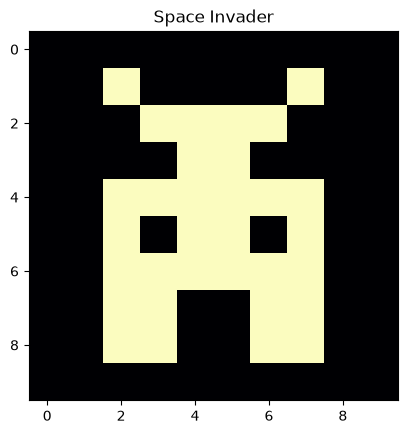

In [71]:
import torch
import matplotlib.pyplot as plt

# 1. Create a 10x10 canvas of zeros
canvas = torch.zeros((10, 10))

# 2. Sculpting the Space Invader using slicing
# Top of the head
canvas[2:4, 4:6] = 1.0
# Main body
canvas[4:7, 2:8] = 1.0
# Antennae
canvas[1, 2] = 1.0
canvas[1, 7] = 1.0
canvas[2, 3] = 1.0
canvas[2, 6] = 1.0
# Carving out the eyes (setting back to 0)
canvas[5, 3] = 0.0
canvas[5, 6] = 0.0
# Legs
canvas[7:9, 2:4] = 1.0
canvas[7:9, 6:8] = 1.0



# Plotting
plt.imshow(canvas.numpy(), cmap='magma') # 'magma' gives a cool retro gaming vibe
plt.title("Space Invader")

plt.show()


In [72]:
# Fun Excercise 2

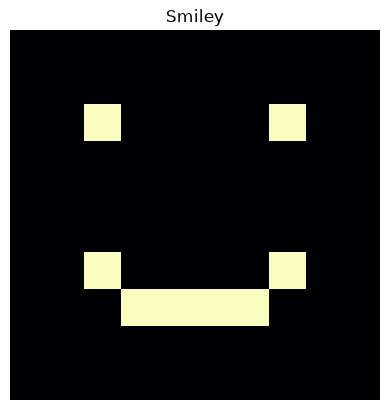

In [73]:
import torch
import matplotlib.pyplot as plt

# 1. Blank canvas (everything starts black/0)
canvas = torch.zeros((10, 10))

# 2. Only light up the eyes
canvas[2, 2] = 1.0
canvas[2, 7] = 1.0

# 3. Only light up the mouth (a line)
canvas[6, 2] = 1.0
canvas[7, 3:7] = 1.0
canvas[6, 7] = 1.0

# 4. Plot
plt.imshow(canvas.numpy(), cmap="magma")
plt.title("Smiley")
plt.axis("off")
plt.show()